# Import libraries

In [1]:
import numpy as np
import pandas as pd

### Data loading

In [2]:
# df = pd.read_csv('ForecastDataset.csv')
df = pd.read_csv('data/ForecastDataset_from_2016_To_2024_for_all_SKUs.csv')

In [3]:
df.shape

(1048575, 10)

In [4]:
df.head(-1)

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip
0,AIRD,54522457,12/23/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91403
1,AIRD,54526264,12/28/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91326
2,AIRD,54536438,12/30/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,19806
3,AIRD,54536647,12/31/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,94903
4,AIRD,54537034,12/31/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,MI,48310
...,...,...,...,...,...,...,...,...,...,...
1048569,AIRD,282772,4/29/2024,AD3500 Pre-Filter 3pk,1.0,10AD350PRF03,Filter,email,WA,98247
1048570,AIRD,282916,4/29/2024,AD3500 1-Year Filter Combo Pack,2.0,10AD350CMPK1,Filter,email,GA,31907
1048571,AIRD,282605,4/29/2024,AD3500 1-Year Filter Combo Pack,1.0,10AD350CMPK1,Filter,paid_search,NY,11764
1048572,AIRD,282606,4/29/2024,AD5500 1-Year Filter Combo Pack,1.0,10AD550CMPK1,Filter,email,CO,80634


In [214]:
df.shape

(1048575, 10)

In [215]:
df.columns

Index(['ProductFamily', 'Order_ID', 'OrderDate', 'SKU_Description',
       'WareHouseQuantity', 'SKU', 'SKU_category', 'Channel', 'ShipToState',
       'ShippingZip'],
      dtype='object')

In [216]:
df.shape

(1048575, 10)

In [217]:
df.drop(['ShippingZip'], axis=1, inplace=True)

In [218]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState
0,AIRD,54522457,12/23/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA
1,AIRD,54526264,12/28/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA
2,AIRD,54536438,12/30/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE
3,AIRD,54536647,12/31/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA
4,AIRD,54537034,12/31/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,MI


In [219]:
df.nunique()

ProductFamily             1
Order_ID             763423
OrderDate              2648
SKU_Description          86
WareHouseQuantity        24
SKU                      93
SKU_category              9
Channel                  33
ShipToState              98
dtype: int64

In [220]:
df.isna().sum()

ProductFamily            0
Order_ID                 0
OrderDate                0
SKU_Description      54667
WareHouseQuantity     4955
SKU                  10630
SKU_category         59623
Channel              12431
ShipToState            240
dtype: int64

In [221]:
df.dropna(inplace=True)

In [222]:
df.isna().sum()

ProductFamily        0
Order_ID             0
OrderDate            0
SKU_Description      0
WareHouseQuantity    0
SKU                  0
SKU_category         0
Channel              0
ShipToState          0
dtype: int64

In [223]:
df.shape

(976283, 9)

### Feature Engineering

In [224]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year

In [225]:
df.head(-1)

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,Week,Month,Year
0,AIRD,54522457,2016-12-23,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,2016-12-19,12,2016
1,AIRD,54526264,2016-12-28,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,2016-12-26,12,2016
2,AIRD,54536438,2016-12-30,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,2016-12-26,12,2016
3,AIRD,54536647,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,2016-12-26,12,2016
4,AIRD,54537034,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,MI,2016-12-26,12,2016
...,...,...,...,...,...,...,...,...,...,...,...,...
1048569,AIRD,282772,2024-04-29,AD3500 Pre-Filter 3pk,1.0,10AD350PRF03,Filter,email,WA,2024-04-29,4,2024
1048570,AIRD,282916,2024-04-29,AD3500 1-Year Filter Combo Pack,2.0,10AD350CMPK1,Filter,email,GA,2024-04-29,4,2024
1048571,AIRD,282605,2024-04-29,AD3500 1-Year Filter Combo Pack,1.0,10AD350CMPK1,Filter,paid_search,NY,2024-04-29,4,2024
1048572,AIRD,282606,2024-04-29,AD5500 1-Year Filter Combo Pack,1.0,10AD550CMPK1,Filter,email,CO,2024-04-29,4,2024


In [226]:
df.nunique()

ProductFamily             1
Order_ID             723549
OrderDate              2648
SKU_Description          84
WareHouseQuantity        24
SKU                      85
SKU_category              9
Channel                  33
ShipToState              93
Week                    385
Month                    12
Year                      9
dtype: int64

In [227]:
df['Channel'].unique()

array(['WEB_Radial', 'UDSOE_Radial', 'SF_Radial', 'Digital_Radial',
       'SMS_Radial', 'TEST_Radial', 'EMAIL_Radial', 'DIG_INFLCR_Radial',
       'DIG_PDSCL_Radial', 'DIG_OTHER_Radial', 'DIG_ORGSCL_Radial',
       'SEM_Radial', 'LVP-DRPRT_Radial', 'AFFILIATE_Radial', 'Main',
       'paid_social', 'organic_social', 'affiliate_email', 'email',
       'affiliate_social', 'affiliates', 'affiliate_publisher',
       'paid_search', 'native', 'Paid_Search', 'LVP_DRTESF',
       'Drop Shipper', 'podcast', 'TRN_DRTESF', 'other', 'TRN_DRTELF',
       'TV', 'customer_service'], dtype=object)

In [228]:
len(df['Channel'].unique())

33

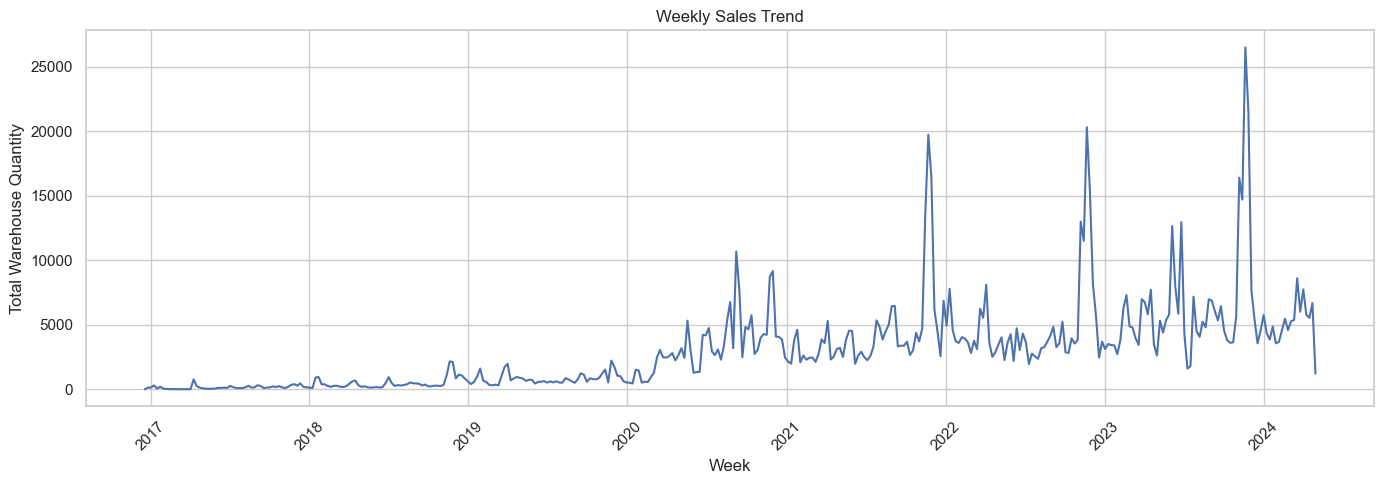

In [229]:
import matplotlib.pyplot as plt
import seaborn as sns

weekly_trend = df.groupby('Week')['WareHouseQuantity'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=weekly_trend, x='Week', y='WareHouseQuantity')
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Total Warehouse Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [230]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,Week,Month,Year
0,AIRD,54522457,2016-12-23,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,2016-12-19,12,2016
1,AIRD,54526264,2016-12-28,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,2016-12-26,12,2016
2,AIRD,54536438,2016-12-30,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,2016-12-26,12,2016
3,AIRD,54536647,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,2016-12-26,12,2016
4,AIRD,54537034,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,MI,2016-12-26,12,2016


### Monthly Orders

C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_35176\4119952867.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_35176\4119952867.py:23: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



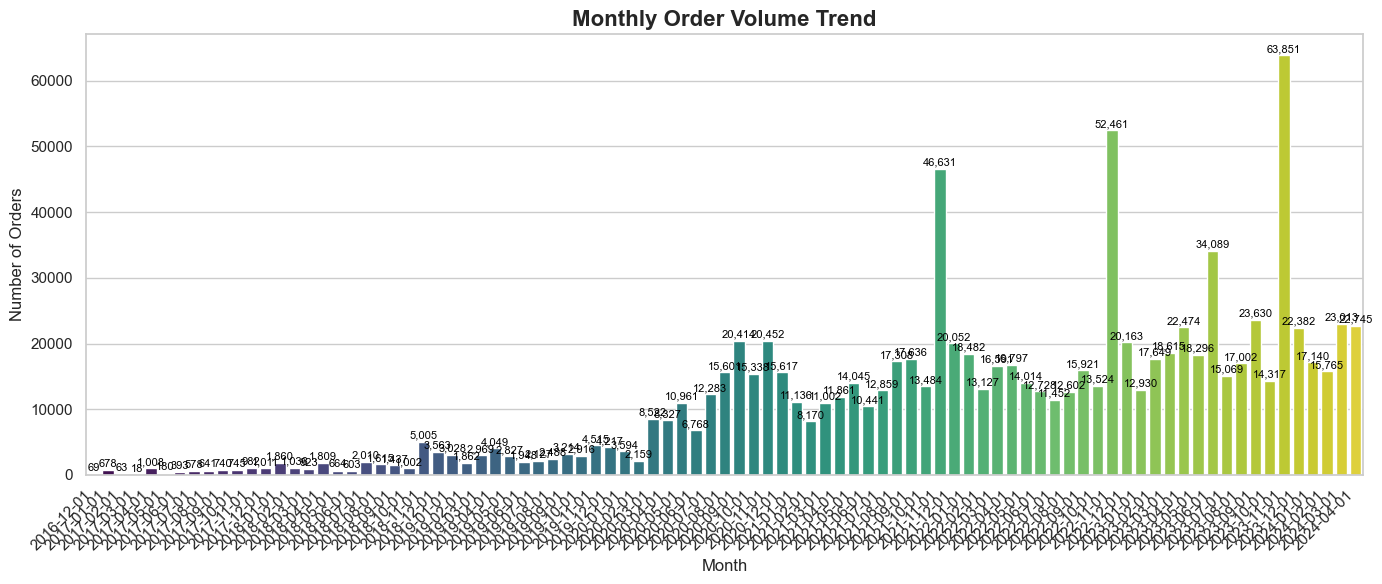

In [231]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Month' is a datetime object
df['Month'] = df['OrderDate'].dt.to_period('M').dt.to_timestamp()
monthly_trend = df.groupby('Month').size().reset_index(name='OrderCount')

# Set theme and size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Plot bar chart
palette = sns.color_palette("viridis", len(monthly_trend))
barplot = sns.barplot(data=monthly_trend, x='Month', y='OrderCount', palette=palette)

# Set titles and labels
plt.title("Monthly Order Volume Trend", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

# Rotate x-axis labels for clarity
barplot.set_xticklabels(barplot.get_xticklabels(), rotation=45, ha='right')

# Annotate each bar
for index, row in monthly_trend.iterrows():
    barplot.text(index, row.OrderCount + 500, f"{row.OrderCount:,}", color='black', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


### Monthly Sales Trend

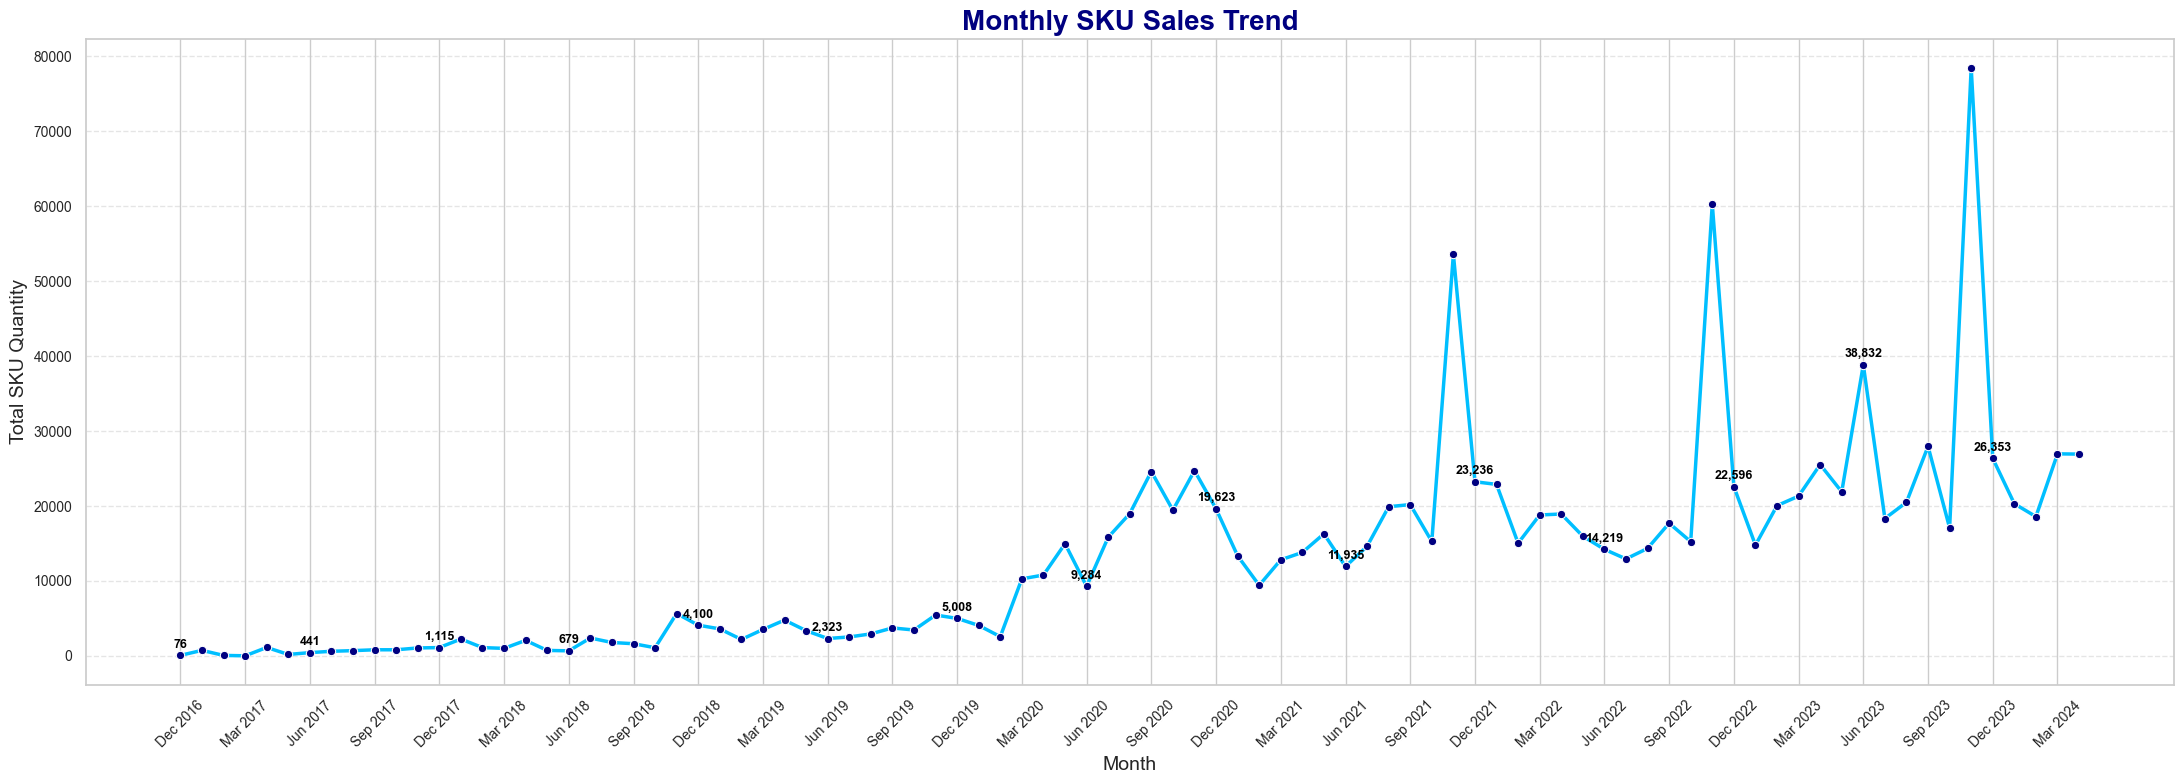

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure Month is datetime
df['Month'] = pd.to_datetime(df['Month'])

# Create readable label
df['Month_Label'] = df['Month'].dt.strftime('%b %Y')

# Aggregate
monthly_trend = df.groupby(['Month', 'Month_Label'])['WareHouseQuantity'].sum().reset_index()
monthly_trend = monthly_trend.sort_values('Month')

# Plot setup
plt.figure(figsize=(22, 8))
sns.set_style("whitegrid")

# Lineplot with marker
sns.lineplot(data=monthly_trend, x='Month_Label', y='WareHouseQuantity',
             marker='o', linewidth=2.5, color='deepskyblue', markerfacecolor='navy')

# Add labels to selected points (e.g., every 6 months)
for i in range(0, len(monthly_trend), 6):
    plt.text(i,
             monthly_trend['WareHouseQuantity'].iloc[i] + 1000,
             f"{monthly_trend['WareHouseQuantity'].iloc[i]:,.0f}",
             ha='center',
             fontsize=9,
             color='black',
             fontweight='bold')

# Title and axis styling
plt.title("Monthly SKU Sales Trend", fontsize=20, fontweight='bold', color='navy')
plt.xlabel("Month", fontsize=14)
plt.ylabel("Total SKU Quantity", fontsize=14)
plt.xticks(ticks=range(0, len(monthly_trend), 3),
           labels=monthly_trend['Month_Label'].iloc[::3],
           rotation=45, fontsize=10)

plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Weekly Order Trends

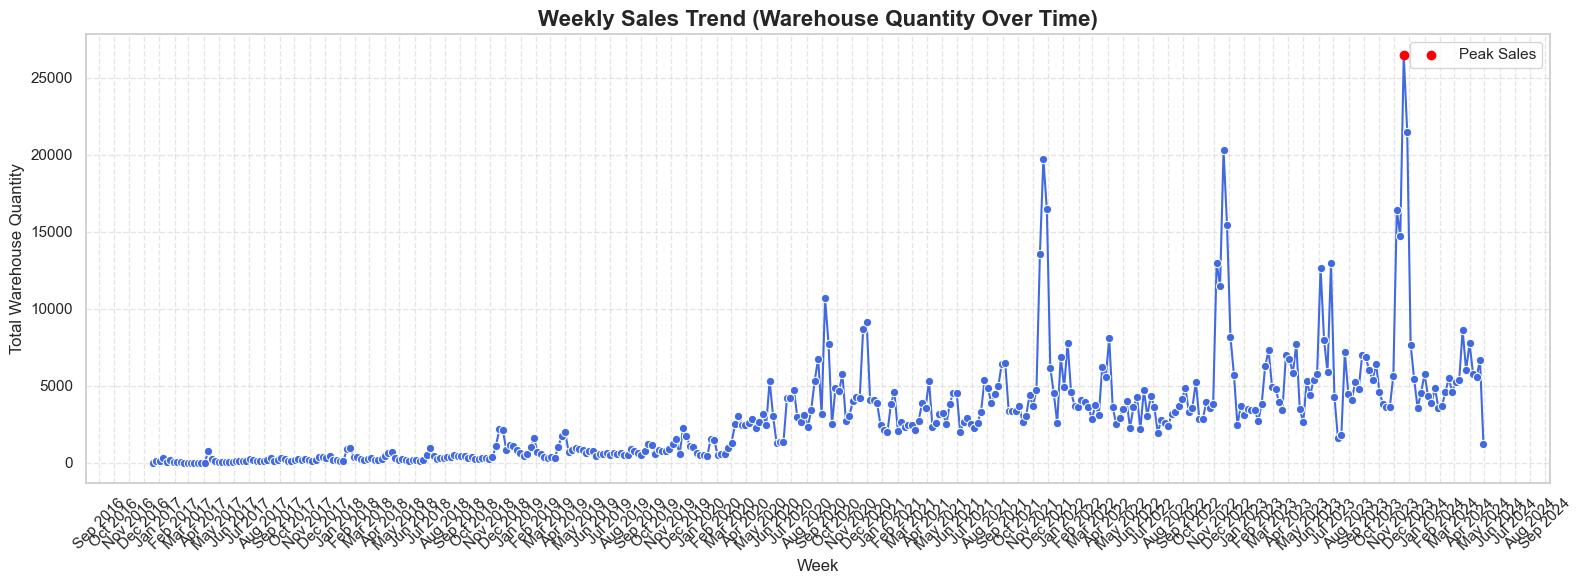

In [233]:
import matplotlib.dates as mdates

# Convert 'Week' to datetime if not already
weekly_trend['Week'] = pd.to_datetime(weekly_trend['Week'])

# Plot
plt.figure(figsize=(16, 6))
sns.lineplot(data=weekly_trend, x='Week', y='WareHouseQuantity', marker='o', color='royalblue')

# Title and labels
plt.title("Weekly Sales Trend (Warehouse Quantity Over Time)", fontsize=16, fontweight='bold')
plt.xlabel("Week", fontsize=12)
plt.ylabel("Total Warehouse Quantity", fontsize=12)

# Format X-axis to show only one label per month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Optional: show every 2nd month to reduce clutter
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Highlight peak
peak = weekly_trend[weekly_trend['WareHouseQuantity'] == weekly_trend['WareHouseQuantity'].max()]
plt.scatter(peak['Week'], peak['WareHouseQuantity'], color='red', label='Peak Sales', zorder=5)
plt.legend()

plt.tight_layout()
plt.show()


In [234]:
print(weekly_trend.columns)


Index(['Week', 'WareHouseQuantity'], dtype='object')


In [235]:
import plotly.express as px

fig = px.line(
    weekly_trend,
    x='Week',
    y='WareHouseQuantity',
    title="Weekly Sales Trend (WareHouse Quantity Over Time)",
)

fig.update_traces(mode='lines+markers', line_color='deepskyblue', marker=dict(size=6))

fig.update_layout(
    width=1600,
    height=600,
    xaxis_title="Week",
    yaxis_title="Total WareHouse Quantity",
    hovermode="x unified",
    template='plotly_dark',  # 🔧 Dark theme here
    
    # X-axis setup for weekly clarity
    xaxis=dict(
        tickformat="%d-%b",
        tickangle=45,
        tickmode='linear',
        tick0=weekly_trend['Week'].min(),
        dtick=604800000,  # One week in ms
        rangeslider=dict(visible=True)
    )
)

fig.show()


### WareHouseQuantity By Channel

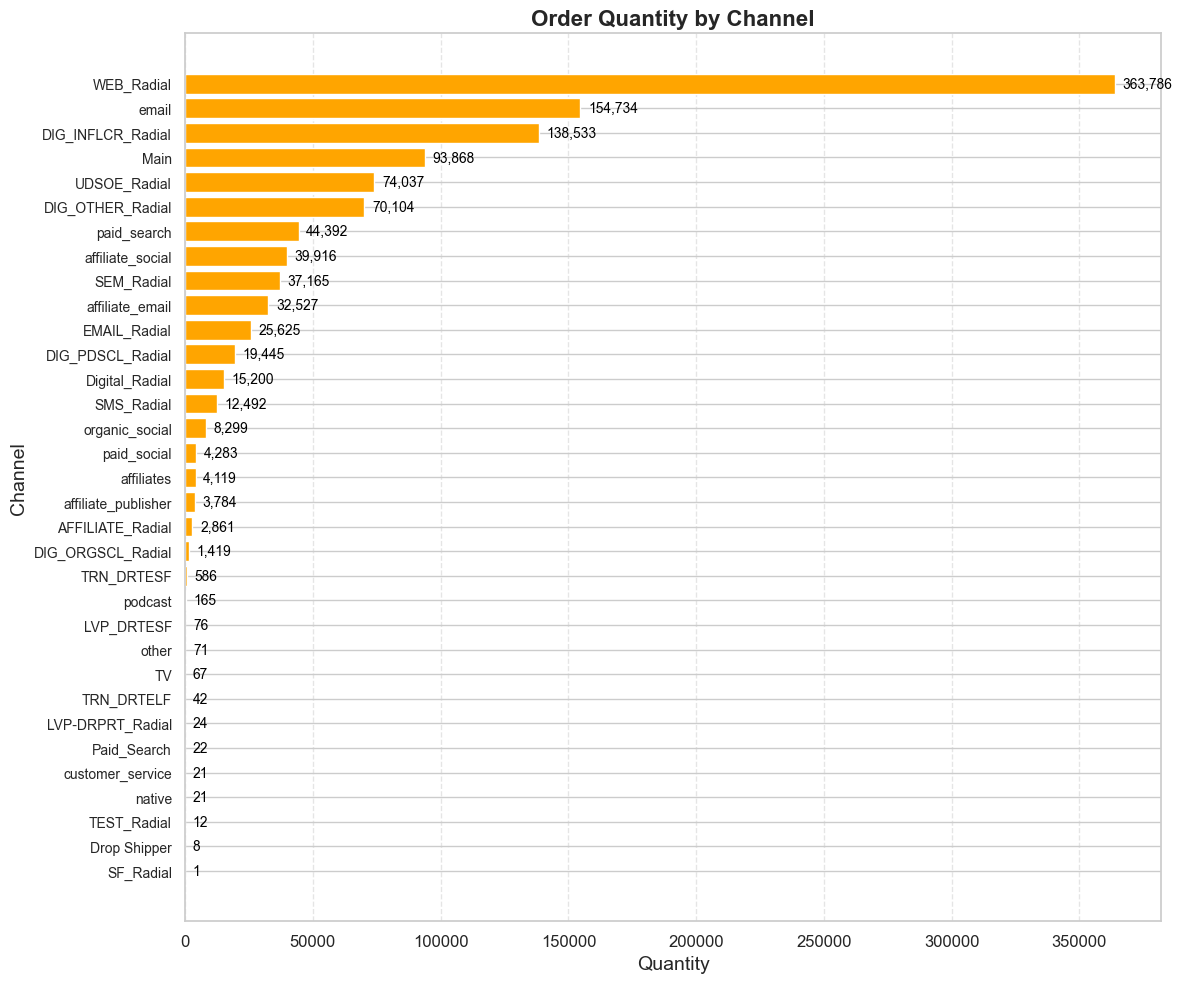

In [236]:
import matplotlib.pyplot as plt
import pandas as pd

# Aggregate and sort
channel_orders = df.groupby('Channel')['WareHouseQuantity'].sum().sort_values(ascending=True)

# Increase figure size
plt.figure(figsize=(12, 10))

# Plot
bars = plt.barh(channel_orders.index, channel_orders.values, color='orange')

# Title and axis labels
plt.title('Order Quantity by Channel', fontsize=16, fontweight='bold')
plt.xlabel('Quantity', fontsize=14)
plt.ylabel('Channel', fontsize=14)

# Add quantity labels to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 3000,               # offset to the right
             bar.get_y() + bar.get_height()/2,
             f'{int(width):,}',          # format with comma
             va='center', fontsize=10, color='black')

# Improve layout
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


In [250]:
df['Channel'].value_counts()

Channel
WEB_Radial             311017
email                  127651
DIG_INFLCR_Radial      125465
Main                    77418
UDSOE_Radial            59852
DIG_OTHER_Radial        59010
paid_search             37075
affiliate_social        35457
SEM_Radial              32922
affiliate_email         27876
EMAIL_Radial            22151
DIG_PDSCL_Radial        17180
Digital_Radial          12368
SMS_Radial               8191
organic_social           7235
paid_social              3728
affiliates               3623
affiliate_publisher      3243
AFFILIATE_Radial         2553
DIG_ORGSCL_Radial        1296
TRN_DRTESF                573
LVP_DRTESF                 73
other                      71
TV                         67
podcast                    50
TRN_DRTELF                 40
LVP-DRPRT_Radial           23
Paid_Search                21
native                     18
customer_service           18
TEST_Radial                 9
Drop Shipper                8
SF_Radial                   1
Na

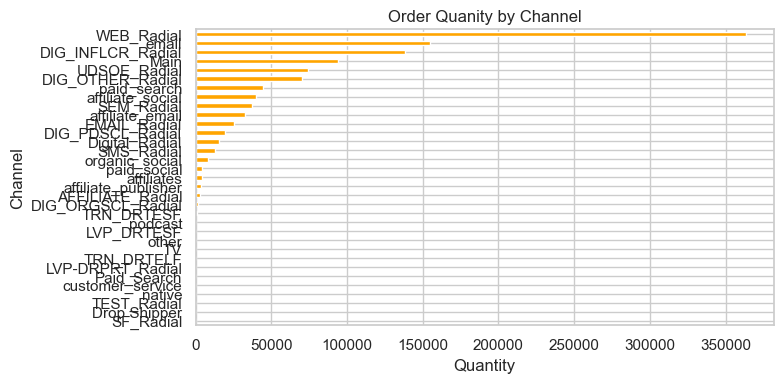

In [251]:
channel_orders = df.groupby('Channel')['WareHouseQuantity'].sum().sort_values()

plt.figure(figsize=(8,4))
channel_orders.plot(kind='barh', color='orange')
plt.title('Order Quanity by Channel')
plt.xlabel('Quantity')
plt.tight_layout()
plt.show()

In [239]:
df['Channel'].value_counts()

Channel
WEB_Radial             311017
email                  127651
DIG_INFLCR_Radial      125465
Main                    77418
UDSOE_Radial            59852
DIG_OTHER_Radial        59010
paid_search             37075
affiliate_social        35457
SEM_Radial              32922
affiliate_email         27876
EMAIL_Radial            22151
DIG_PDSCL_Radial        17180
Digital_Radial          12368
SMS_Radial               8191
organic_social           7235
paid_social              3728
affiliates               3623
affiliate_publisher      3243
AFFILIATE_Radial         2553
DIG_ORGSCL_Radial        1296
TRN_DRTESF                573
LVP_DRTESF                 73
other                      71
TV                         67
podcast                    50
TRN_DRTELF                 40
LVP-DRPRT_Radial           23
Paid_Search                21
native                     18
customer_service           18
TEST_Radial                 9
Drop Shipper                8
SF_Radial                   1
Na

### Top SKU

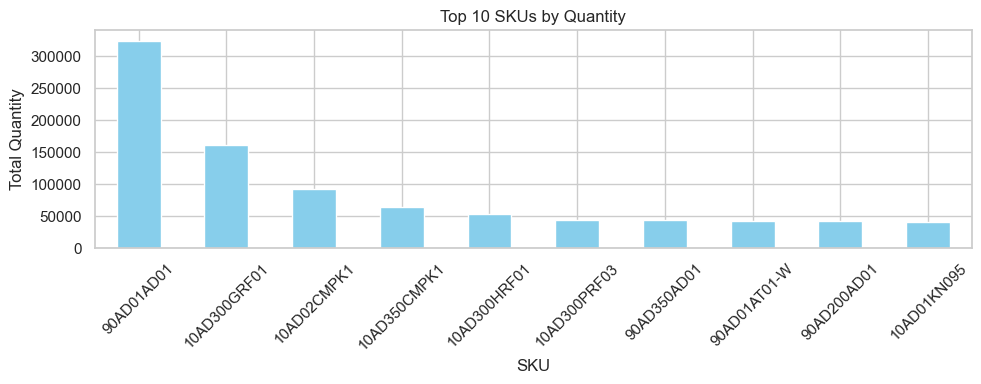

In [240]:
top_skus = df.groupby('SKU')['WareHouseQuantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
top_skus.plot(kind='bar', color='skyblue')
plt.title("Top 10 SKUs by Quantity")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [241]:
top_skus

SKU
90AD01AD01      324507.0
10AD300GRF01    161435.0
10AD02CMPK1      92262.0
10AD350CMPK1     64549.0
10AD300HRF01     53605.0
10AD300PRF03     44365.0
90AD350AD01      44134.0
90AD01AT01-W     42981.0
90AD200AD01      42487.0
10AD01KN095      40568.0
Name: WareHouseQuantity, dtype: float64

### On Full Dataset

21:19:39 - cmdstanpy - INFO - Chain [1] start processing
21:19:40 - cmdstanpy - INFO - Chain [1] done processing


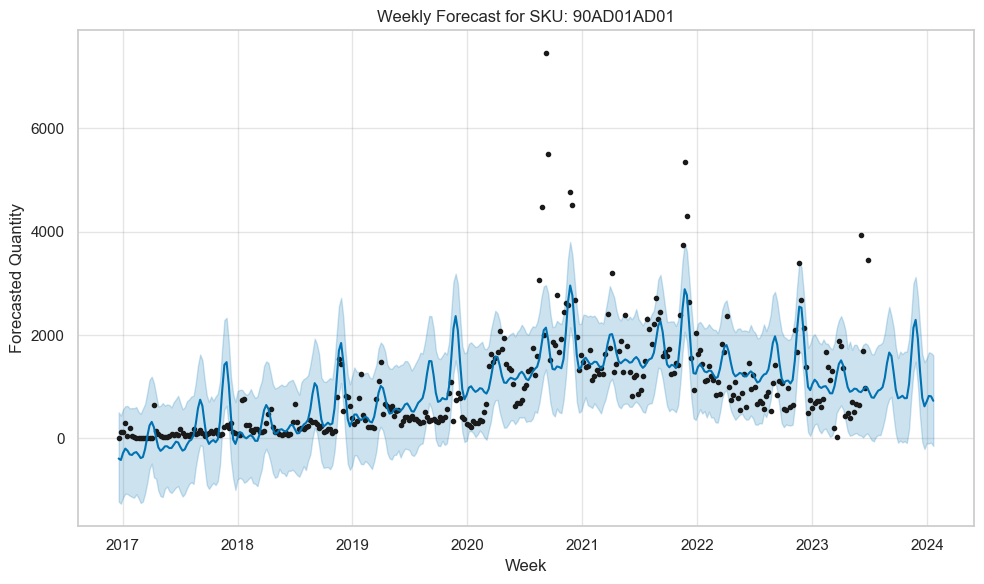

            ds         yhat   yhat_lower   yhat_upper
359 2023-11-05  1049.635615   175.368418  1912.874701
360 2023-11-12  1601.154412   793.404323  2392.379474
361 2023-11-19  2142.337945  1282.597103  3001.690301
362 2023-11-26  2294.103490  1480.038854  3125.062416
363 2023-12-03  1929.977818  1036.005860  2757.210151
364 2023-12-10  1294.527150   411.654791  2152.542882
365 2023-12-17   784.826087   -66.920910  1624.236214
366 2023-12-24   619.437389  -206.608298  1474.981980
367 2023-12-31   710.424916   -95.234948  1543.481815
368 2024-01-07   821.825190   -96.799028  1666.594240
369 2024-01-14   813.524376   -83.040052  1650.283778
370 2024-01-21   727.051532  -147.976758  1609.956768


In [252]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# STEP 1: Convert OrderDate to weekly
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)

# STEP 2: Group by Week and SKU
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuantity'].sum().reset_index()

# STEP 3: Filter for SKU = '90AD01AD01'
sku = '90AD01AD01'
df_sku = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuantity']].copy()
df_sku.columns = ['ds', 'y']

# Skip if there are too few data points
if len(df_sku) < 10:
    print(f"Not enough data for SKU: {sku} ({len(df_sku)} weeks)")
else:
    # Fit Prophet model
    model = Prophet()
    model.fit(df_sku)

    # Forecast 30 weeks ahead
    future = model.make_future_dataframe(periods=30, freq='W')
    forecast = model.predict(future)

    # Plot the forecast
    model.plot(forecast)
    plt.title(f"Weekly Forecast for SKU: {sku}")
    plt.xlabel("Week")
    plt.ylabel("Forecasted Quantity")
    plt.tight_layout()
    plt.show()

    # Optional: View forecast
    result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    print(result.tail(12))


### Using 80-20 Data Splitting

21:23:00 - cmdstanpy - INFO - Chain [1] start processing


METHOD 1: TRAIN-TEST SPLIT VALIDATION
Training data points: 272
Testing data points: 69


21:23:00 - cmdstanpy - INFO - Chain [1] done processing



Accuracy Metrics:
MAE (Mean Absolute Error): 1345.92
MSE (Mean Squared Error): 2093178.62
RMSE (Root Mean Squared Error): 1446.78
MAPE (Mean Absolute Percentage Error): 314.42%
R² Score: -2.84


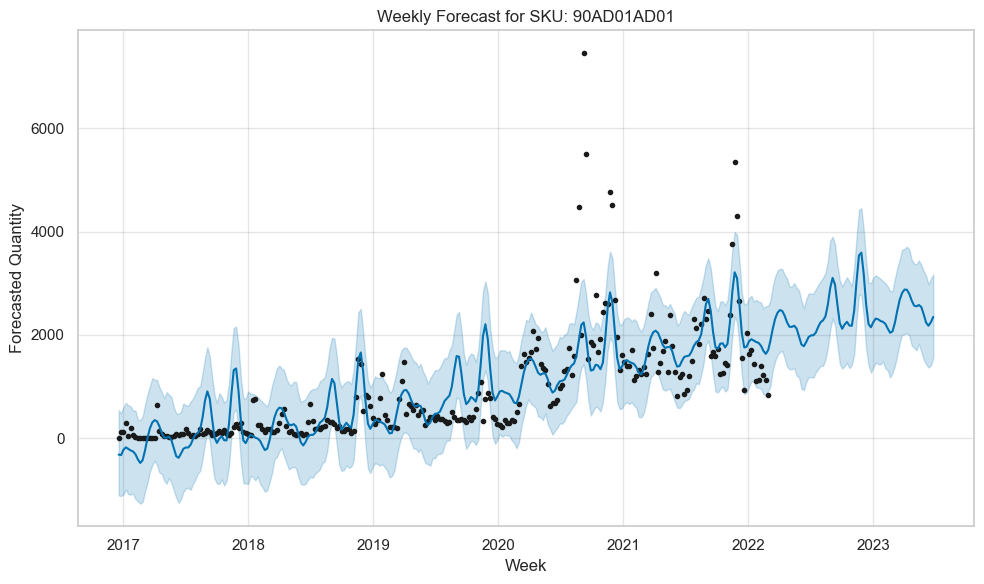

In [253]:
import pandas as pd
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# Your existing code for data preparation
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuantity'].sum().reset_index()

sku = '90AD01AD01'
df_sku = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuantity']].copy()
df_sku.columns = ['ds', 'y']

if len(df_sku) < 10:
    print(f"Not enough data for SKU: {sku} ({len(df_sku)} weeks)")
else:
    # METHOD 1: TRAIN-TEST SPLIT VALIDATION
    print("=" * 50)
    print("METHOD 1: TRAIN-TEST SPLIT VALIDATION")
    print("=" * 50)
    
    # Split data: use 80% for training, 20% for testing
    train_size = int(len(df_sku) * 0.8)
    train_data = df_sku[:train_size]
    test_data = df_sku[train_size:]
    
    print(f"Training data points: {len(train_data)}")
    print(f"Testing data points: {len(test_data)}")
    
    # Train model on training data
    model_train = Prophet()
    # model_train = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.01)
    # model_train = Prophet(weekly_seasonality=True, yearly_seasonality=True)

    model_train.fit(train_data)
    
    # Predict on test period
    future_test = model_train.make_future_dataframe(periods=len(test_data), freq='W')
    forecast_test = model_train.predict(future_test)
    
    # Get predictions for test period only
    test_predictions = forecast_test.tail(len(test_data))
    
    # Calculate accuracy metrics
    actual = test_data['y'].values
    predicted = test_predictions['yhat'].values
    
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    r2 = r2_score(actual, predicted)

    print(f"\nAccuracy Metrics:")
    print(f"MAE (Mean Absolute Error): {mae:.2f}")
    print(f"MSE (Mean Squared Error): {mse:.2f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
    print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
    print(f"R² Score: {r2:.2f}")

    # Plot the forecast
    model_train.plot(forecast_test)
    plt.title(f"Weekly Forecast for SKU: {sku}")
    plt.xlabel("Week")
    plt.ylabel("Forecasted Quantity")
    plt.tight_layout()
    plt.show()

In [254]:
df_sku.head(-1)

,ds,y
0,2016-12-19,1.0
1,2016-12-26,127.0
2,2017-01-02,127.0
3,2017-01-09,294.0
4,2017-01-16,47.0
...,...,...
3896,2023-05-22,667.0
3934,2023-05-29,638.0
3976,2023-06-05,3945.0
4017,2023-06-12,1691.0


### Range Of SKUs

In [255]:
# Minimum date for the entire dataset
print("Full dataset date range:", df['OrderDate'].min(), "to", df['OrderDate'].max())

# Minimum date for the selected SKU
sku = '90AD01AD01'
df_sku_check = df[df['SKU'] == sku]
print(f"Selected SKU date range {sku}: ", df_sku_check['OrderDate'].min(), "to", df_sku_check['OrderDate'].max())

# Count of rows for the SKU
# print("Total weekly data points for this SKU:", df_sku_check.shape[0])

sku = '10AD350CMPK1'
df_sku_check = df[df['SKU'] == sku]
print(f"Selected SKU date range {sku}:", df_sku_check['OrderDate'].min(), "to", df_sku_check['OrderDate'].max())

sku = '10AD02CMPK1'
df_sku_check = df[df['SKU'] == sku]
print(f"Selected SKU date range {sku}:", df_sku_check['OrderDate'].min(), "to", df_sku_check['OrderDate'].max())

Full dataset date range: 2016-12-23 00:00:00 to 2024-04-29 00:00:00
Selected SKU date range 90AD01AD01:  2016-12-23 00:00:00 to 2023-07-01 00:00:00
Selected SKU date range 10AD350CMPK1: 2023-06-28 00:00:00 to 2024-04-29 00:00:00
Selected SKU date range 10AD02CMPK1: 2017-04-19 00:00:00 to 2024-04-29 00:00:00


In [256]:
top_skus

SKU
90AD01AD01      324507.0
10AD300GRF01    161435.0
10AD02CMPK1      92262.0
10AD350CMPK1     64549.0
10AD300HRF01     53605.0
10AD300PRF03     44365.0
90AD350AD01      44134.0
90AD01AT01-W     42981.0
90AD200AD01      42487.0
10AD01KN095      40568.0
Name: WareHouseQuantity, dtype: float64

### Data Splitting: Training and Testing (For Checking Accuracy)
- For Testing :  Jan, Feb, March, April 2023
- Rest of the data for Training 

In [258]:
import pandas as pd

# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create 'Week' column as week start date (Monday)
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)

# Group weekly by SKU
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuantity'].sum().reset_index()

# Filter for the specific SKU
sku = '10AD02CMPK1'
df_sku_weekly = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuantity']].copy()

# Add week start and end dates
df_sku_weekly['Week_Start'] = df_sku_weekly['Week']
df_sku_weekly['Week_End'] = df_sku_weekly['Week_Start'] + pd.Timedelta(days=6)

# Filter Test Data: Only May and June 2025
# Filter Test Data: Only weeks strictly within May and June 2025
test_data = df_sku_weekly[
    (df_sku_weekly['Week_Start'] >= pd.to_datetime('2024-01-01')) &
    (df_sku_weekly['Week_Start'] < pd.to_datetime('2024-04-29'))  # Exclude 2025-06-30 week
]


# Filter Train Data: Before May 2025 (strictly excludes May, June, July)
train_data = df_sku_weekly[
    df_sku_weekly['Week_Start'] < pd.to_datetime('2024-01-01')
]

# Final output
print("Train Data:")
print(train_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].tail())

print("\nTest Data:")
print(test_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].head())


Train Data:
     Week_Start   Week_End  WareHouseQuantity
5145 2023-11-27 2023-12-03             1556.0
5200 2023-12-04 2023-12-10              306.0
5254 2023-12-11 2023-12-17              306.0
5302 2023-12-18 2023-12-24              166.0
5353 2023-12-25 2023-12-31               87.0

Test Data:
     Week_Start   Week_End  WareHouseQuantity
5402 2024-01-01 2024-01-07              254.0
5448 2024-01-08 2024-01-14               41.0
5492 2024-01-15 2024-01-21               87.0
5539 2024-01-22 2024-01-28              231.0
5584 2024-01-29 2024-02-04               19.0


In [259]:
train_data.head(-1)

,Week,WareHouseQuantity,Week_Start,Week_End
22,2017-04-17,31.0,2017-04-17,2017-04-23
26,2017-04-24,10.0,2017-04-24,2017-04-30
30,2017-05-01,2.0,2017-05-01,2017-05-07
43,2017-05-29,1.0,2017-05-29,2017-06-04
62,2017-07-03,1.0,2017-07-03,2017-07-09
...,...,...,...,...
5090,2023-11-20,2688.0,2023-11-20,2023-11-26
5145,2023-11-27,1556.0,2023-11-27,2023-12-03
5200,2023-12-04,306.0,2023-12-04,2023-12-10
5254,2023-12-11,306.0,2023-12-11,2023-12-17


In [263]:
# Check available weeks in 2025
print(df_sku_weekly[df_sku_weekly['Week_Start'].dt.year == 2024]['Week_Start'].unique())


<DatetimeArray>
['2024-01-01 00:00:00', '2024-01-08 00:00:00', '2024-01-15 00:00:00',
 '2024-01-22 00:00:00', '2024-01-29 00:00:00', '2024-02-05 00:00:00',
 '2024-02-12 00:00:00', '2024-02-19 00:00:00', '2024-02-26 00:00:00',
 '2024-03-04 00:00:00', '2024-03-11 00:00:00', '2024-03-18 00:00:00',
 '2024-03-25 00:00:00', '2024-04-01 00:00:00', '2024-04-08 00:00:00',
 '2024-04-15 00:00:00', '2024-04-22 00:00:00', '2024-04-29 00:00:00']
Length: 18, dtype: datetime64[ns]


In [264]:
# df['Year'] = df['OrderDate'].dt.year
# sku_2025 = df[df['Year'] == 2025]['SKU'].unique()
# print("SKUs with data in 2025:", sku_2025)


21:37:21 - cmdstanpy - INFO - Chain [1] start processing
21:37:21 - cmdstanpy - INFO - Chain [1] done processing


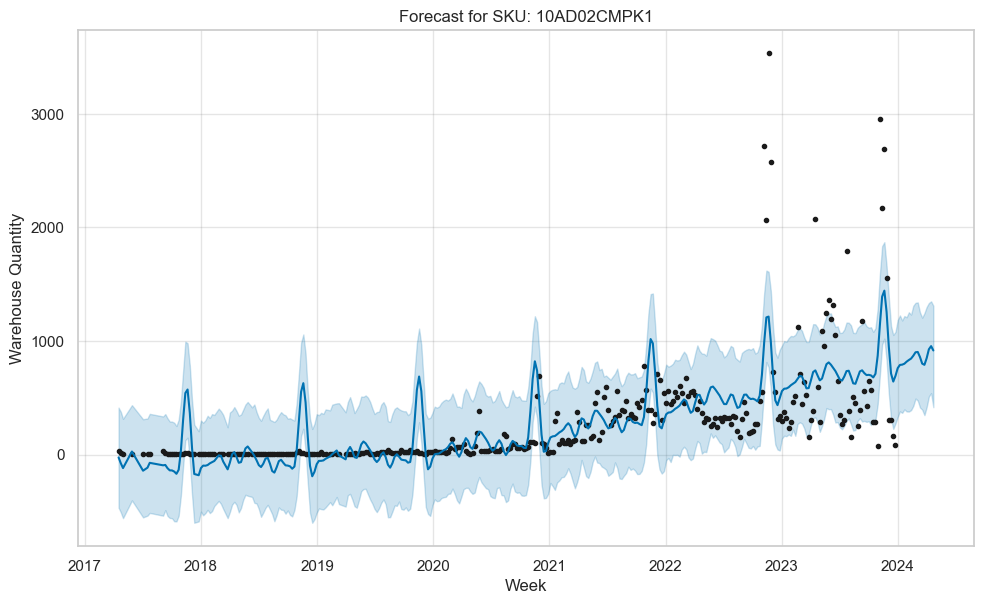


Forecast vs Actuals (Jan to April 2024):
            ds        yhat  WareHouseQuantity
329 2024-01-01  761.324229              254.0
330 2024-01-08  789.544876               41.0
331 2024-01-15  791.866545               87.0
332 2024-01-22  800.198228              231.0
333 2024-01-29  818.245004               19.0
334 2024-02-05  832.663395               41.0
335 2024-02-12  845.402786               67.0
336 2024-02-19  870.456159              157.0
337 2024-02-26  901.042516               84.0
338 2024-03-04  903.532862              349.0
339 2024-03-11  859.005924              219.0
340 2024-03-18  800.815499              246.0
341 2024-03-25  790.254472               45.0
342 2024-04-01  848.764247              130.0
343 2024-04-08  927.160270              173.0
344 2024-04-15  954.949327               91.0
345 2024-04-22  916.879234               78.0

Accuracy Metrics:
MAE  (Mean Absolute Error):        711.77
MSE  (Mean Squared Error):         517786.98
RMSE (Root Mean Squared 

In [268]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

# STEP 3: Create future dataframe covering May and June 2025
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')  # weekly on Mondays

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.show()

# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuantity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (Jan to April 2024):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'yhat', 'WareHouseQuantity']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns for clarity
test_forecast.rename(columns={
    'WareHouseQuantity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop rows with missing values
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Extract values
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

# Calculate metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# Print all metrics
print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")



21:48:05 - cmdstanpy - INFO - Chain [1] start processing



Training Data Range: 2017-04-17 to 2023-12-25
 - Total Years:  7
 - Total Months: 81
 - Total Weeks:  329

Testing Data Range:  2024-01-01 to 2024-04-22
 - Total Years:  1
 - Total Months: 4
 - Total Weeks:  17


21:48:05 - cmdstanpy - INFO - Chain [1] done processing


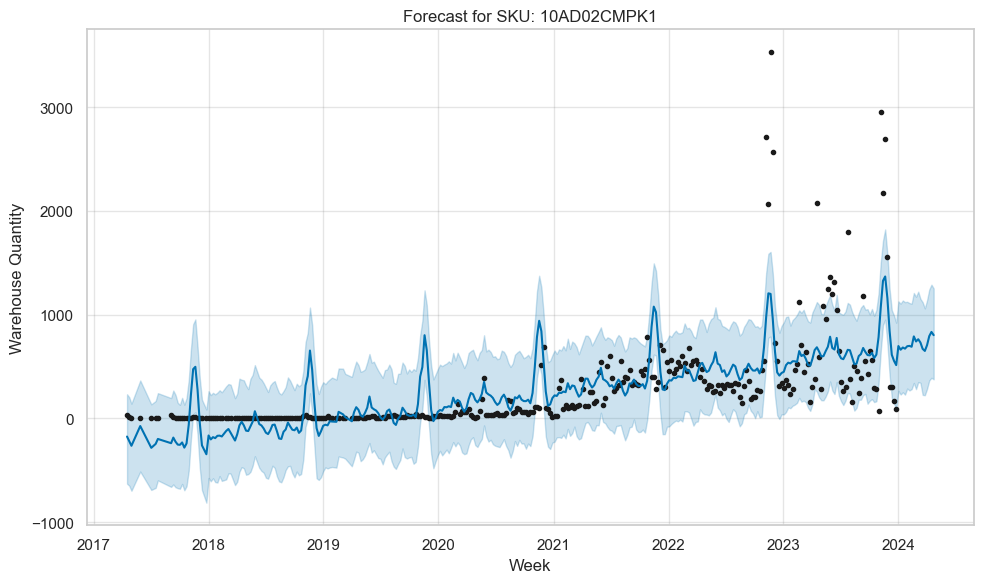

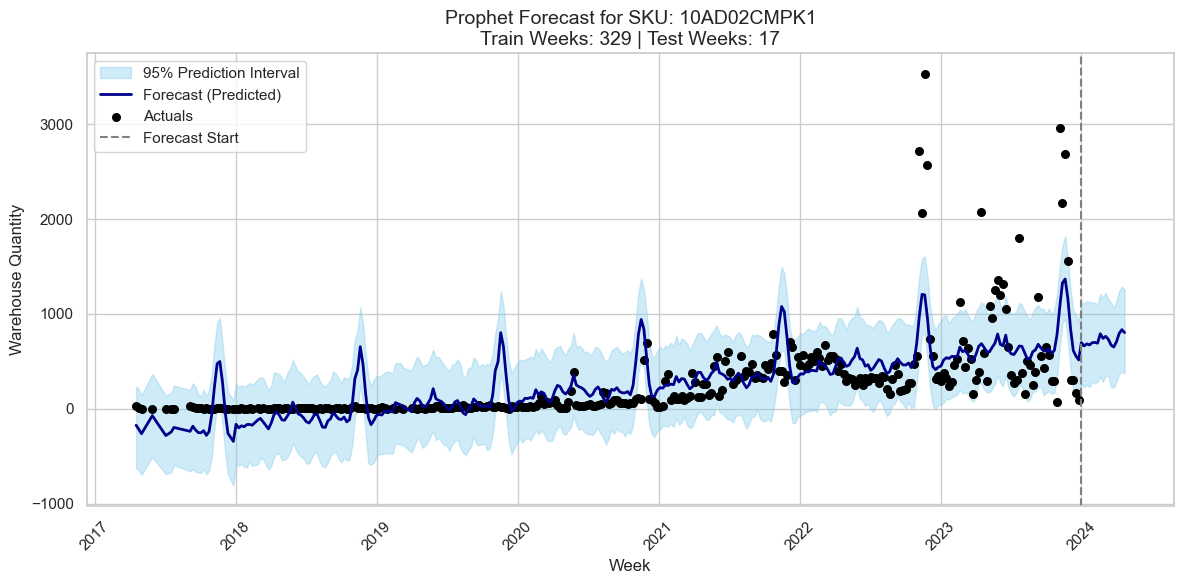


Forecast vs Actuals (January to April 2024):
            ds  WareHouseQuantity        yhat
329 2024-01-01              254.0  697.603826
330 2024-01-08               41.0  662.116928
331 2024-01-15               87.0  683.499008
332 2024-01-22              231.0  672.638914
333 2024-01-29               19.0  695.778828
334 2024-02-05               41.0  699.302349
335 2024-02-12               67.0  690.904208
336 2024-02-19              157.0  790.561642
337 2024-02-26               84.0  741.879417
338 2024-03-04              349.0  763.427296
339 2024-03-11              219.0  731.313590
340 2024-03-18              246.0  670.557251
341 2024-03-25               45.0  650.601215
342 2024-04-01              130.0  706.437666
343 2024-04-08              173.0  793.362012
344 2024-04-15               91.0  833.771925
345 2024-04-22               78.0  802.596037

Accuracy Metrics:
MAE  (Mean Absolute Error):        586.73
MSE  (Mean Squared Error):         354316.24
RMSE (Root Mean Squa

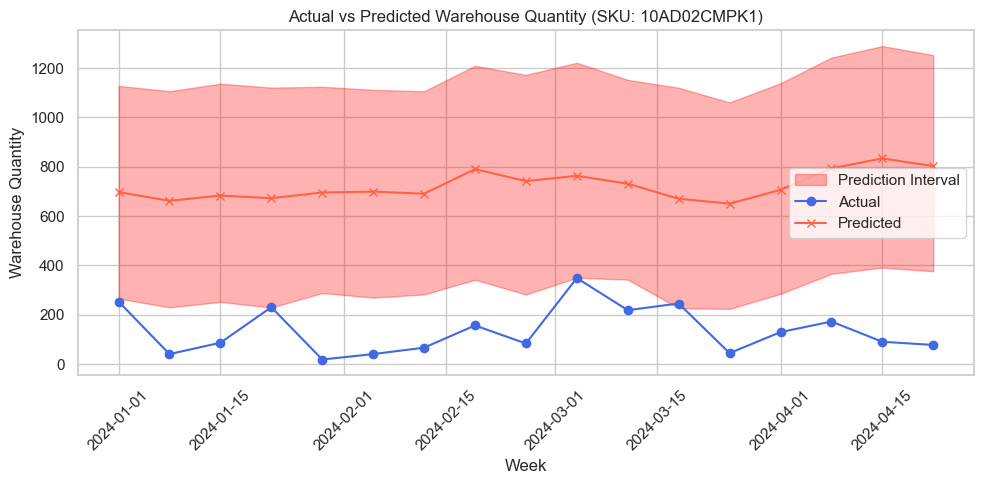


Final Forecast Results with Percent Difference:


,Start_Week,End_Week,Actual_WareHouseQuanity,Predicted_WareHouseQuanity,Difference_Between_Predicted_And_Actual,Percent_Difference
329,2024-01-01,2024-01-07,254.0,697.603826,443.603826,174.65%
330,2024-01-08,2024-01-14,41.0,662.116928,621.116928,1514.92%
331,2024-01-15,2024-01-21,87.0,683.499008,596.499008,685.63%
332,2024-01-22,2024-01-28,231.0,672.638914,441.638914,191.19%
333,2024-01-29,2024-02-04,19.0,695.778828,676.778828,3561.99%
334,2024-02-05,2024-02-11,41.0,699.302349,658.302349,1605.62%
335,2024-02-12,2024-02-18,67.0,690.904208,623.904208,931.2%
336,2024-02-19,2024-02-25,157.0,790.561642,633.561642,403.54%
337,2024-02-26,2024-03-03,84.0,741.879417,657.879417,783.19%
338,2024-03-04,2024-03-10,349.0,763.427296,414.427296,118.75%


In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(
    growth='linear',
    yearly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=0.010,
    seasonality_prior_scale=20,
    holidays_prior_scale=20
)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)

# STEP 3: Create future dataframe covering test period
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval(Using Prophet default)
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5 (Updated): Enhanced Forecast Plot

# Extract historical actuals
historical = prophet_df.copy()
historical['label'] = 'Actuals'

# Prepare forecast line
forecast_plot = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_plot['label'] = 'Forecast'

# Plot setup
plt.figure(figsize=(12, 6))

# Confidence interval
plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='skyblue', alpha=0.4, label='95% Prediction Interval')

# Forecast line
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], color='darkblue', label='Forecast (Predicted)', linewidth=2)

# Actuals as scatter points
plt.scatter(historical['ds'], historical['y'], color='black', label='Actuals', s=30)

# Vertical line for training-test boundary
test_boundary = test_data['Week_Start'].min()
plt.axvline(x=test_boundary, color='gray', linestyle='--', label='Forecast Start')

# Title with time span info
plt.title(f"Prophet Forecast for SKU: {sku}\nTrain Weeks: {train_weeks} | Test Weeks: {test_weeks}", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuantity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (January to April 2024):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuantity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns
test_forecast.rename(columns={
    'WareHouseQuantity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop missing
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Metrics
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted with interval
plt.figure(figsize=(10, 5))
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 9: Create final result DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']

# New: Add Percent Difference column
test_forecast['Percent_Difference'] = (
    test_forecast['Difference_Between_Predicted_And_Actual'] / test_forecast['actual']
) * 100

# Create final result
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuanity',
    'predicted': 'Predicted_WareHouseQuanity'
}, inplace=True)

# Round and add percent sign
final_result['Percent_Difference'] = final_result['Percent_Difference'].round(2).astype(str) + '%'



# Optional: Save to CSV
# final_result.to_csv("actual_vs_predicted_forecast_results.csv", index=False)

# Print final result
print("\nFinal Forecast Results with Percent Difference:")
final_result


### Using `seasonality_mode='multiplicative'`

23:42:32 - cmdstanpy - INFO - Chain [1] start processing



Training Data Range: 2017-04-17 to 2023-12-25
 - Total Years:  7
 - Total Months: 81
 - Total Weeks:  329

Testing Data Range:  2024-01-01 to 2024-04-29
 - Total Years:  1
 - Total Months: 4
 - Total Weeks:  18


23:42:32 - cmdstanpy - INFO - Chain [1] done processing


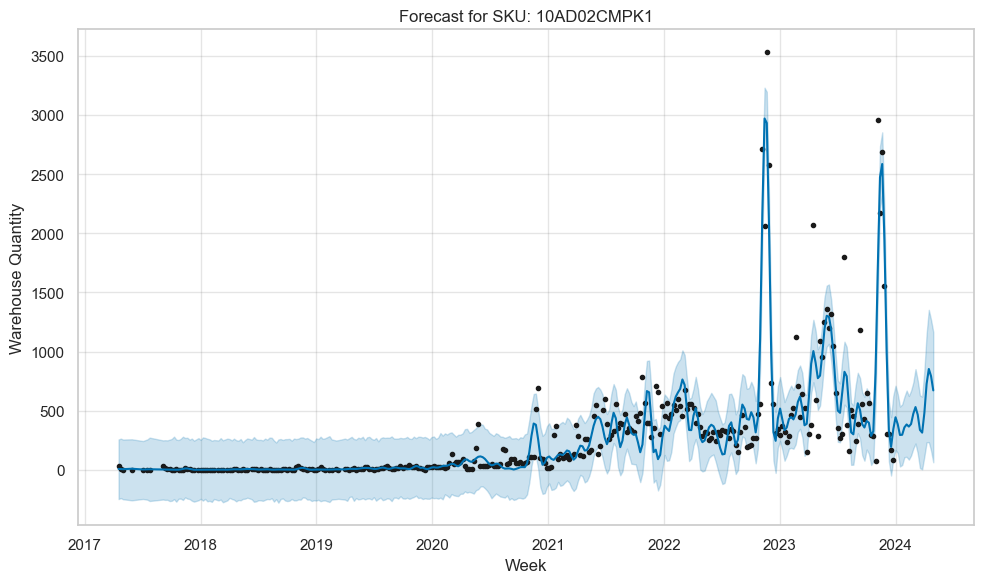

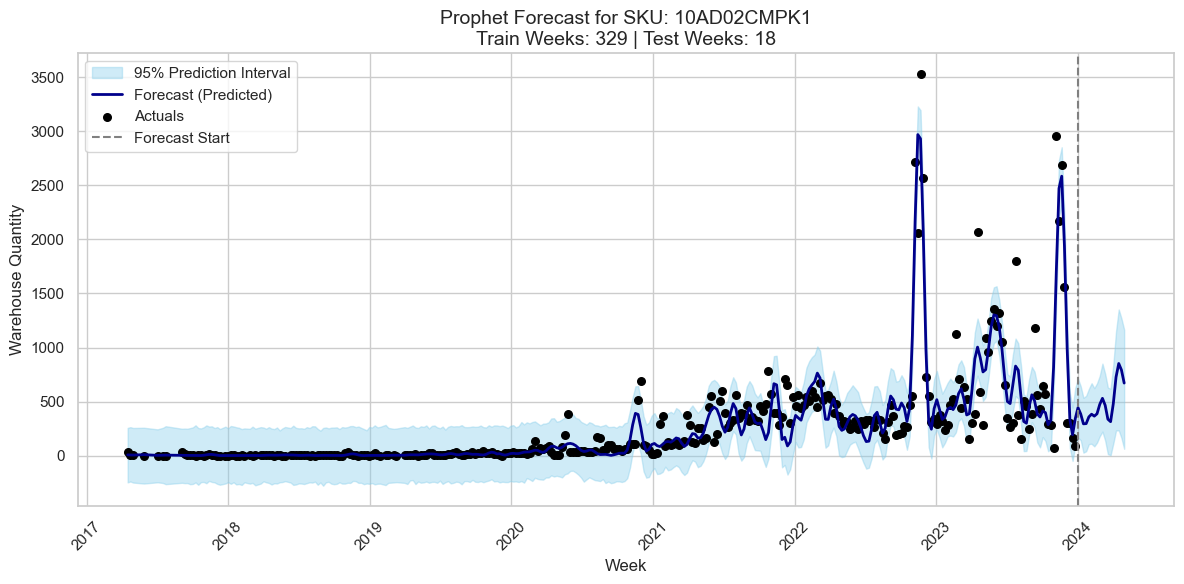


Forecast vs Actuals (January to April 2024):
            ds  WareHouseQuantity        yhat
329 2024-01-01              254.0  444.453452
330 2024-01-08               41.0  385.356785
331 2024-01-15               87.0  294.716016
332 2024-01-22              231.0  296.677835
333 2024-01-29               19.0  359.055082
334 2024-02-05               41.0  383.855562
335 2024-02-12               67.0  365.907920
336 2024-02-19              157.0  387.760227
337 2024-02-26               84.0  474.013682
338 2024-03-04              349.0  530.773280
339 2024-03-11              219.0  466.186210
340 2024-03-18              246.0  337.850582
341 2024-03-25               45.0  314.766465
342 2024-04-01              130.0  482.133126
343 2024-04-08              173.0  726.946007
344 2024-04-15               91.0  852.691957
345 2024-04-22               78.0  792.323392
346 2024-04-29               14.0  671.686394

Accuracy Metrics:
MAE  (Mean Absolute Error):        346.73
MSE  (Mean Squared 

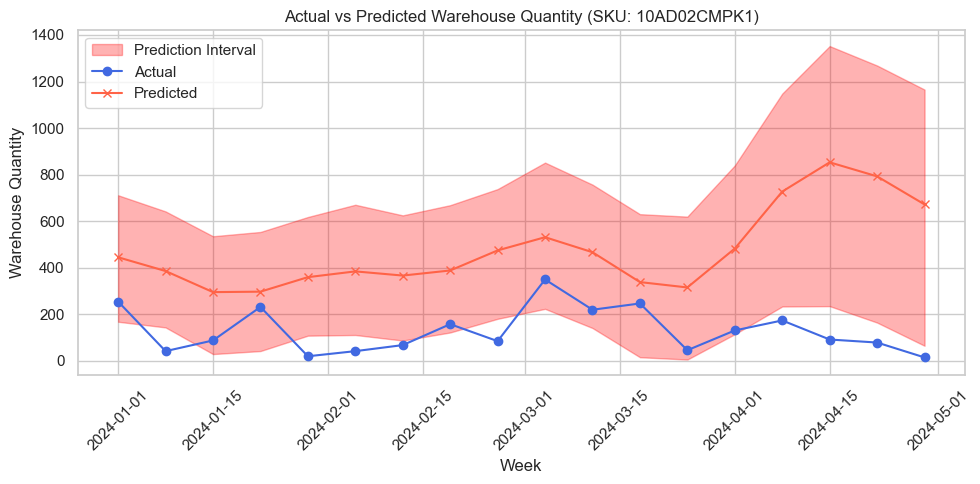


Final Forecast Results with Percent Difference:


,Start_Week,End_Week,Actual_WareHouseQuanity,Predicted_WareHouseQuanity,Difference_Between_Predicted_And_Actual,Percent_Difference
329,2024-01-01,2024-01-07,254.0,444.453452,190.453452,74.98%
330,2024-01-08,2024-01-14,41.0,385.356785,344.356785,839.89%
331,2024-01-15,2024-01-21,87.0,294.716016,207.716016,238.75%
332,2024-01-22,2024-01-28,231.0,296.677835,65.677835,28.43%
333,2024-01-29,2024-02-04,19.0,359.055082,340.055082,1789.76%
334,2024-02-05,2024-02-11,41.0,383.855562,342.855562,836.23%
335,2024-02-12,2024-02-18,67.0,365.907920,298.907920,446.13%
336,2024-02-19,2024-02-25,157.0,387.760227,230.760227,146.98%
337,2024-02-26,2024-03-03,84.0,474.013682,390.013682,464.3%
338,2024-03-04,2024-03-10,349.0,530.773280,181.773280,52.08%


In [286]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(
    # growth='linear',
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=5.0,
    seasonality_prior_scale=15.0,
    holidays_prior_scale=0.02498426688347824
)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)

 

# STEP 3: Create future dataframe covering test period
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval(Using Prophet default)
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5 (Updated): Enhanced Forecast Plot

# Extract historical actuals
historical = prophet_df.copy()
historical['label'] = 'Actuals'

# Prepare forecast line
forecast_plot = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_plot['label'] = 'Forecast'

# Plot setup
plt.figure(figsize=(12, 6))

# Confidence interval
plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='skyblue', alpha=0.4, label='95% Prediction Interval')

# Forecast line
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], color='darkblue', label='Forecast (Predicted)', linewidth=2)

# Actuals as scatter points
plt.scatter(historical['ds'], historical['y'], color='black', label='Actuals', s=30)

# Vertical line for training-test boundary
test_boundary = test_data['Week_Start'].min()
plt.axvline(x=test_boundary, color='gray', linestyle='--', label='Forecast Start')

# Title with time span info
plt.title(f"Prophet Forecast for SKU: {sku}\nTrain Weeks: {train_weeks} | Test Weeks: {test_weeks}", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuantity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (January to April 2024):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuantity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns
test_forecast.rename(columns={
    'WareHouseQuantity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop missing
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Metrics
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted with interval
plt.figure(figsize=(10, 5))
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 9: Create final result DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']

# New: Add Percent Difference column
test_forecast['Percent_Difference'] = (
    test_forecast['Difference_Between_Predicted_And_Actual'] / test_forecast['actual']
) * 100

# Create final result
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuanity',
    'predicted': 'Predicted_WareHouseQuanity'
}, inplace=True)

# Round and add percent sign
final_result['Percent_Difference'] = final_result['Percent_Difference'].round(2).astype(str) + '%'



# Optional: Save to CSV
# final_result.to_csv("actual_vs_predicted_forecast_results.csv", index=False)

# Print final result
print("\nFinal Forecast Results with Percent Difference:")
final_result


In [282]:
import pandas as pd
from prophet import Prophet
import optuna
from sklearn.metrics import mean_absolute_error

# ----------------------------
# Prepare data
# ----------------------------
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuantity'].sum().reset_index()

# Filter specific SKU
sku = '10AD02CMPK1'
df_sku_weekly = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuantity']].copy()
df_sku_weekly['Week_Start'] = df_sku_weekly['Week']
df_sku_weekly['Week_End'] = df_sku_weekly['Week_Start'] + pd.Timedelta(days=6)

# Split train/test
train_data = df_sku_weekly[df_sku_weekly['Week_Start'] < pd.to_datetime('2024-01-01')]
test_data = df_sku_weekly[
    (df_sku_weekly['Week_Start'] >= pd.to_datetime('2024-01-01')) &
    (df_sku_weekly['Week_Start'] < pd.to_datetime('2024-04-30'))
]

# Prophet format
train_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'})
test_df = test_data[['Week_Start', 'WareHouseQuantity']].rename(columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'})

# ----------------------------
# Define objective function
# ----------------------------
def objective(trial):
    params = {
        'changepoint_prior_scale': trial.suggest_categorical('changepoint_prior_scale', [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]),
        'seasonality_prior_scale': trial.suggest_categorical('seasonality_prior_scale', [1.0, 5.0, 10.0, 15.0, 20.0,40.0, 50.0]),
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative']),
        'growth': 'linear',
        'weekly_seasonality': trial.suggest_categorical('weekly_seasonality', [True, False]),
        'yearly_seasonality': trial.suggest_categorical('yearly_seasonality', [True, False]),
        'holidays_prior_scale': trial.suggest_float('holidays_prior_scale', 0.001, 0.1, log=True),
        'daily_seasonality': False,
    }

    model = Prophet(**params)

    # Optional: Add US holidays
    model.add_country_holidays(country_name='US')

    model.fit(train_df)

    future = model.make_future_dataframe(periods=len(test_df), freq='W-MON')
    forecast = model.predict(future)

    forecast_trim = forecast.set_index('ds').loc[test_df['ds']]

    if forecast_trim.empty or len(forecast_trim) != len(test_df):
        raise ValueError("Forecast does not align with test set")

    mae = mean_absolute_error(test_df['y'].values, forecast_trim['yhat'].values)
    return mae

# ----------------------------
# Run optimization
# ----------------------------
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=500)

# ----------------------------
# Best result
# ----------------------------
print("Best Parameters:", study.best_params)
print("Best MAE:", study.best_value)


[I 2025-07-28 23:31:42,554] A new study created in memory with name: no-name-09b6c104-2a75-49aa-bab8-21315e89ab9a
23:31:42 - cmdstanpy - INFO - Chain [1] start processing
23:31:42 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-07-28 23:31:43,161] Trial 0 finished with value: 547.756612060476 and parameters: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True, 'holidays_prior_scale': 0.00316212080963083}. Best is trial 0 with value: 547.756612060476.
23:31:43 - cmdstanpy - INFO - Chain [1] start processing
23:31:43 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-07-28 23:31:43,503] Trial 1 finished with value: 751.735939483193 and parameters: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': True, 'holidays_prior_scale': 0.07640250240472882}. Best is trial 0 with value: 54

Best Parameters: {'changepoint_prior_scale': 5.0, 'seasonality_prior_scale': 15.0, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True, 'holidays_prior_scale': 0.02498426688347824}
Best MAE: 346.73077641874215
